In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [2]:
df = pd.read_csv('../data/processed/cleaned_insurance.csv', index_col=0)
df.head()

,age,sex,bmi,children,smoker,charges
0,19,0,27.900,0,1,16884.92400
1,18,1,33.770,1,0,1725.55230
2,28,1,33.000,3,0,4449.46200
3,33,1,22.705,0,0,21984.47061
4,32,1,28.880,0,0,3866.85520


In [3]:
X = df.drop(columns="charges")
y = df["charges"]

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X)
feature_names = poly.get_feature_names_out(X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=521)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso = LassoCV(cv=5, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

print(f"Lasso R-squared: {lasso.score(X_test_scaled, y_test):.4f}")

Lasso R-squared: 0.8461


In [4]:
df["predictions"] = lasso.predict(scaler.transform(X_poly))
df.head(20)

,age,sex,bmi,children,smoker,charges,predictions
0,19,0,27.900,0,1,16884.92400,23530.263573
1,18,1,33.770,1,0,1725.55230,2215.543076
2,28,1,33.000,3,0,4449.46200,5992.962315
3,33,1,22.705,0,0,21984.47061,5953.381530
4,32,1,28.880,0,0,3866.85520,5627.111833
5,31,0,25.740,0,0,3756.62160,5907.894530
6,46,0,33.440,1,0,8240.58960,10545.459315
7,37,0,27.740,3,0,7281.50560,9122.692445
8,37,1,29.830,2,0,6406.41070,7990.046952
9,60,0,25.840,0,0,28923.13692,13012.599773


In [5]:
(
    pd.Series(lasso.coef_, index=feature_names)
    .to_frame('coef')
    .assign(abs_coef=lambda x: x['coef'].abs())
    .sort_values('abs_coef', ascending=False)
    .drop(columns='abs_coef')
    .round()
)

,coef
bmi smoker,18200.0
smoker,-7825.0
age,2839.0
age bmi,851.0
sex bmi,-631.0
children,600.0
age sex,358.0
children smoker,-220.0
bmi,-149.0
age children,90.0


In [6]:
explainer = shap.LinearExplainer(lasso, X_train_scaled, feature_perturbation="interventional")

c:\Users\markg\AppData\Local\Programs\Python\Python310\lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


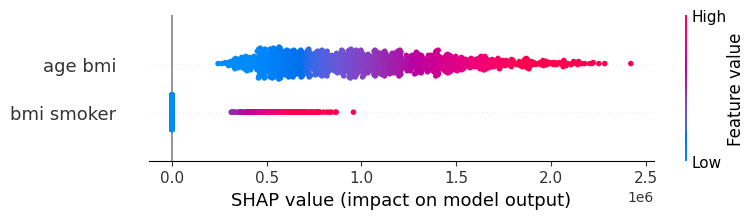

<Figure size 640x480 with 0 Axes>

In [9]:
shap_values = explainer.shap_values(X_poly)

shap.summary_plot(shap_values, X_poly, feature_names=feature_names, max_display=2)
plt.tight_layout()
plt.show()

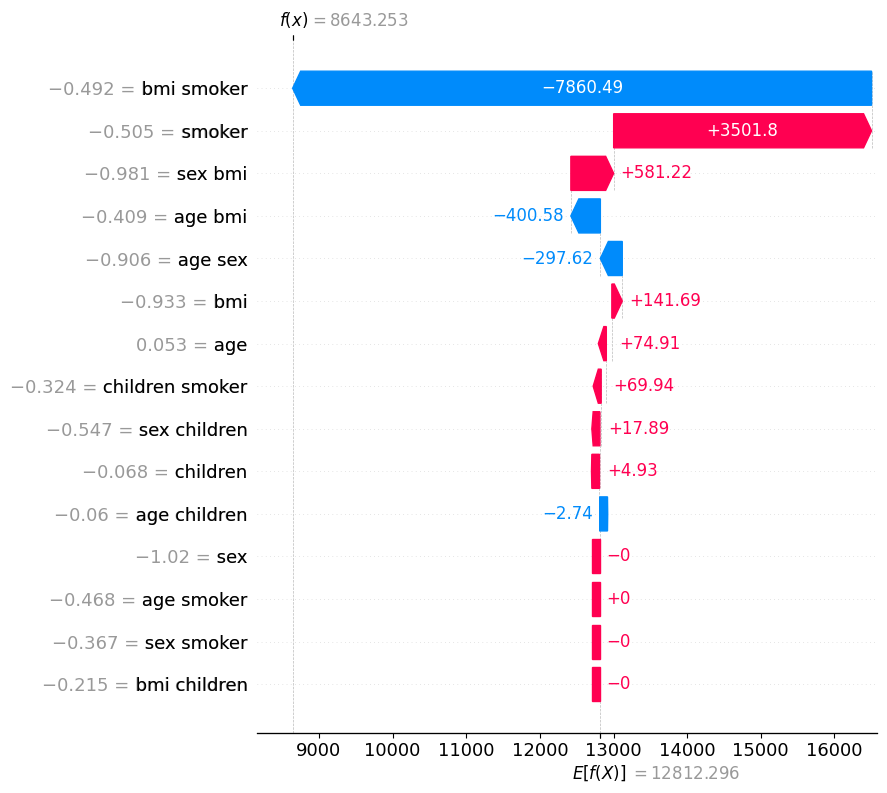

Estimated Insurance Charge: $8,643.25


In [18]:
def predict_insurance_cost(age, sex, bmi, children, smoker):
    person = pd.DataFrame([[age, sex, bmi, children, smoker]], 
                          columns=['age', 'sex', 'bmi', 'children', 'smoker'])
    
    person_poly = poly.transform(person) 
    person_scaled = scaler.transform(person_poly)
    
    prediction = lasso.predict(person_scaled)

    shap_values = explainer(person_scaled)

    shap_values.feature_names = list(feature_names)
    shap.plots.waterfall(shap_values[0], max_display=15)
    
    return f"Estimated Insurance Charge: ${prediction[0]:,.2f}"

print(predict_insurance_cost(40, 0, 25.0, 1, 0))